In [19]:
import os
from typing import Dict, List, Optional, Union, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Global plotting style
sns.set_theme(style="whitegrid")


# File loading
def load_data(file_path: str) -> pd.DataFrame:
    """
    Load a dataset from CSV, Excel, or JSON.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        df = pd.read_csv(file_path)
    elif ext in [".xlsx", ".xls"]:
        df = pd.read_excel(file_path)
    elif ext == ".json":
        df = pd.read_json(file_path)
    else:
        raise ValueError("Unsupported file format. Use CSV, Excel, or JSON.")

    return df


def load_log_file(log_path: Optional[str]) -> pd.DataFrame:
    """
    Load feature engineering log file if available.
    """
    if log_path is None or not os.path.exists(log_path):
        return pd.DataFrame()

    ext = os.path.splitext(log_path)[1].lower()

    if ext == ".csv":
        return pd.read_csv(log_path)
    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(log_path)
    elif ext == ".json":
        return pd.read_json(log_path)
    else:
        raise ValueError("Unsupported log file format. Use CSV, Excel, or JSON.")


# Column detection helpers
def get_numeric_columns(df: pd.DataFrame) -> List[str]:
    """
    Return numeric columns.
    """
    return df.select_dtypes(include=[np.number]).columns.tolist()


def get_categorical_columns(df: pd.DataFrame) -> List[str]:
    """
    Return categorical columns.
    """
    return df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


def get_datetime_columns(df: pd.DataFrame) -> List[str]:
    """
    Return columns already recognized by pandas as datetime.
    """
    return df.select_dtypes(include=["datetime64[ns]", "datetime64", "datetimetz"]).columns.tolist()


def try_parse_datetime_columns(df: pd.DataFrame, threshold: float = 0.8) -> List[str]:
    """
    Detect object columns that look like datetime columns.
    """
    datetime_like = []

    for col in df.columns:
        if df[col].dtype == "object":
            non_null = df[col].dropna()
            if len(non_null) == 0:
                continue

            parsed = pd.to_datetime(non_null, errors="coerce")
            success_rate = parsed.notna().mean()

            if success_rate >= threshold:
                datetime_like.append(col)

    return datetime_like


def get_column_cardinality(df: pd.DataFrame) -> pd.Series:
    """
    Return number of unique values per column.
    """
    return df.nunique(dropna=False).sort_values(ascending=False)


def detect_id_like_columns(df: pd.DataFrame, uniqueness_threshold: float = 0.95) -> List[str]:
    """
    Detect likely ID-like columns.

    Heuristics:
    1. column name contains id / code / number / record / uuid
    2. uniqueness ratio is very high
    """
    id_like = []
    row_count = len(df)

    if row_count == 0:
        return id_like

    keywords = ["id", "code", "number", "record", "uuid"]

    for col in df.columns:
        col_lower = col.lower()
        uniqueness_ratio = df[col].nunique(dropna=False) / row_count

        name_flag = any(keyword in col_lower for keyword in keywords)
        unique_flag = uniqueness_ratio >= uniqueness_threshold

        if name_flag or unique_flag:
            id_like.append(col)

    return sorted(list(set(id_like)))


def get_non_id_numeric_columns(df: pd.DataFrame) -> List[str]:
    """
    Return numeric columns excluding likely ID-like columns.
    """
    numeric_cols = get_numeric_columns(df)
    id_like_cols = detect_id_like_columns(df)
    return [col for col in numeric_cols if col not in id_like_cols]


def get_non_id_categorical_columns(df: pd.DataFrame) -> List[str]:
    """
    Return categorical columns excluding likely ID-like columns.
    """
    categorical_cols = get_categorical_columns(df)
    id_like_cols = detect_id_like_columns(df)
    return [col for col in categorical_cols if col not in id_like_cols]


# Dataset overview
def get_basic_info(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Return basic dataset info.
    """
    return {
        "shape": df.shape,
        "row_count": df.shape[0],
        "column_count": df.shape[1],
        "columns": df.columns.tolist(),
        "dtypes": df.dtypes.astype(str).to_dict(),
    }


def dataset_summary(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Return a dataset summary.
    """
    missing_cells = int(df.isnull().sum().sum())
    total_cells = int(df.shape[0] * df.shape[1]) if df.shape[0] > 0 and df.shape[1] > 0 else 0
    missing_percent_total = (missing_cells / total_cells * 100) if total_cells > 0 else 0.0
    duplicate_rows = int(df.duplicated().sum())

    numeric_cols = get_numeric_columns(df)
    categorical_cols = get_categorical_columns(df)
    datetime_cols = list(set(get_datetime_columns(df) + try_parse_datetime_columns(df)))
    id_like_cols = detect_id_like_columns(df)

    return {
        "row_count": df.shape[0],
        "column_count": df.shape[1],
        "missing_cells_total": missing_cells,
        "missing_percent_total": round(missing_percent_total, 2),
        "duplicate_rows": duplicate_rows,
        "numeric_column_count": len(numeric_cols),
        "categorical_column_count": len(categorical_cols),
        "datetime_column_count": len(datetime_cols),
        "id_like_column_count": len(id_like_cols),
        "numeric_columns": numeric_cols,
        "categorical_columns": categorical_cols,
        "datetime_columns": datetime_cols,
        "id_like_columns": id_like_cols,
    }


def missing_value_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return missing count and percentage for each column.
    """
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df) * 100) if len(df) > 0 else 0

    summary = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent
    }).sort_values(by=["missing_count", "missing_percent"], ascending=False)

    return summary


def numeric_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return descriptive summary for numeric columns.
    """
    numeric_cols = get_numeric_columns(df)
    if not numeric_cols:
        return pd.DataFrame()

    summary = df[numeric_cols].describe().T
    summary["missing_count"] = df[numeric_cols].isnull().sum()
    summary["missing_percent"] = (df[numeric_cols].isnull().sum() / len(df) * 100) if len(df) > 0 else 0

    return summary


def categorical_summary(df: pd.DataFrame, top_n: int = 10) -> Dict[str, pd.DataFrame]:
    """
    Return top category summaries for categorical columns.
    """
    summaries = {}
    categorical_cols = get_categorical_columns(df)

    for col in categorical_cols:
        counts = df[col].value_counts(dropna=False).head(top_n)
        percents = (counts / len(df) * 100) if len(df) > 0 else 0

        summary_df = pd.DataFrame({
            "count": counts,
            "percent": percents
        })

        summaries[col] = summary_df

    return summaries


# Log / metadata integration
def build_transformation_metadata(log_df: pd.DataFrame) -> Dict[str, Dict[str, Any]]:
    """
    Build metadata from standardized feature_log.csv.

    Expected columns:
    - step
    - feature_name
    - method
    - source_columns

    source_columns may contain one or multiple columns separated by commas.
    """
    metadata = {}

    if log_df.empty:
        return metadata

    required_cols = ["step", "feature_name", "method", "source_columns"]
    missing_cols = [col for col in required_cols if col not in log_df.columns]
    if missing_cols:
        raise ValueError(f"Log file is missing required columns: {missing_cols}")

    for _, row in log_df.iterrows():
        feature_name = row["feature_name"]

        if pd.isna(feature_name):
            continue

        raw_sources = row["source_columns"]

        if pd.isna(raw_sources):
            source_list = []
        else:
            source_list = [s.strip() for s in str(raw_sources).split(",") if s.strip()]

        metadata[str(feature_name)] = {
            "step": row["step"],
            "method": str(row["method"]),
            "source_columns": source_list,
            "is_engineered": True
        }

    return metadata


def get_engineered_columns(df: pd.DataFrame, metadata: Dict[str, Dict[str, Any]]) -> List[str]:
    """
    Return engineered columns that appear in the dataset.
    """
    return [col for col in df.columns if col in metadata]


def get_original_columns(df: pd.DataFrame, metadata: Dict[str, Dict[str, Any]]) -> List[str]:
    """
    Return non-engineered columns.
    """
    return [col for col in df.columns if col not in metadata]


def classify_columns_with_metadata(df: pd.DataFrame, metadata: Dict[str, Dict[str, Any]]) -> Dict[str, List[str]]:
    """
    Return original vs engineered column groups.
    """
    return {
        "original_columns": get_original_columns(df, metadata),
        "engineered_columns": get_engineered_columns(df, metadata)
    }


def build_feature_summary_table(metadata: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    """
    Convert feature metadata into a readable table.
    """
    if not metadata:
        return pd.DataFrame(columns=["feature", "step", "method", "source_columns", "is_engineered"])

    rows = []
    for feature, info in metadata.items():
        rows.append({
            "feature": feature,
            "step": info.get("step"),
            "method": info.get("method"),
            "source_columns": ", ".join(info.get("source_columns", [])),
            "is_engineered": info.get("is_engineered", False)
        })

    return pd.DataFrame(rows)


def get_feature_lineage(feature_name: str, metadata: Dict[str, Dict[str, Any]]) -> Dict[str, Any]:
    """
    Return lineage information for one feature.
    """
    if feature_name not in metadata:
        return {
            "feature": feature_name,
            "is_engineered": False,
            "step": None,
            "method": None,
            "source_columns": []
        }

    info = metadata[feature_name].copy()
    info["feature"] = feature_name
    return info


# Filtering
def filter_data(df: pd.DataFrame, filters: Optional[Dict[str, Any]] = None) -> pd.DataFrame:
    """
    Flexible filtering.

    Supported forms:
    1. exact match:
       {"gender": "Male"}

    2. multiple allowed values:
       {"city": ["New York", "Los Angeles", "Chicago"]}

    3. numeric range:
       {"age": {"min": 20, "max": 40}}

    4. one-sided numeric range:
       {"income": {"min": 50000}}

    5. substring search:
       {"name": {"contains": "john"}}
    """
    filtered_df = df.copy()

    if filters is None:
        return filtered_df

    for column, condition in filters.items():
        if column not in filtered_df.columns:
            raise KeyError(f"Column '{column}' not found in DataFrame.")

        if isinstance(condition, dict):
            if "min" in condition:
                filtered_df = filtered_df[filtered_df[column] >= condition["min"]]
            if "max" in condition:
                filtered_df = filtered_df[filtered_df[column] <= condition["max"]]
            if "contains" in condition:
                filtered_df = filtered_df[
                    filtered_df[column].astype(str).str.contains(
                        str(condition["contains"]), case=False, na=False
                    )
                ]

        elif isinstance(condition, list):
            filtered_df = filtered_df[filtered_df[column].isin(condition)]

        else:
            filtered_df = filtered_df[filtered_df[column] == condition]

    return filtered_df


# Plot validators and helpers
def _validate_column_exists(df: pd.DataFrame, column: str) -> None:
    if column not in df.columns:
        raise KeyError(f"Column '{column}' not found in dataset.")


def _validate_numeric_column(df: pd.DataFrame, column: str) -> None:
    _validate_column_exists(df, column)
    if column not in get_numeric_columns(df):
        raise TypeError(f"Column '{column}' must be numeric.")


def _validate_categorical_column(df: pd.DataFrame, column: str) -> None:
    _validate_column_exists(df, column)
    if column not in get_categorical_columns(df):
        raise TypeError(f"Column '{column}' must be categorical.")


def _finalize_plot(save_path: Optional[str] = None, show: bool = True) -> None:
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()


# Plot functions
def plot_histogram(
    df: pd.DataFrame,
    column: str,
    bins: int = 30,
    kde: bool = True,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    Histogram for numeric column.
    """
    _validate_numeric_column(df, column)

    data = df[column].dropna()
    if data.empty:
        raise ValueError(f"Column '{column}' has no non-missing values to plot.")

    plt.figure(figsize=(8, 5))
    sns.histplot(data, bins=bins, kde=kde)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    _finalize_plot(save_path, show)


def plot_boxplot(
    df: pd.DataFrame,
    column: str,
    by: Optional[str] = None,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    Boxplot for numeric column.
    Optionally group by another column.
    """
    _validate_numeric_column(df, column)

    plt.figure(figsize=(9, 5))

    if by is None:
        sns.boxplot(x=df[column])
        plt.title(f"Boxplot of {column}")
        plt.xlabel(column)
    else:
        _validate_column_exists(df, by)
        sns.boxplot(data=df, x=by, y=column)
        plt.title(f"Boxplot of {column} by {by}")
        plt.xlabel(by)
        plt.ylabel(column)
        plt.xticks(rotation=45)

    _finalize_plot(save_path, show)


def plot_countplot(
    df: pd.DataFrame,
    column: str,
    top_n: int = 20,
    include_missing: bool = True,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    Countplot for categorical column with top_n protection.
    """
    _validate_column_exists(df, column)

    plot_series = df[column].copy()

    if include_missing:
        plot_series = plot_series.fillna("Missing")
    else:
        plot_series = plot_series.dropna()

    counts = plot_series.value_counts().head(top_n)
    plot_df = pd.DataFrame({
        column: counts.index.astype(str),
        "count": counts.values
    })

    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x=column, y="count")
    plt.title(f"Top {min(top_n, len(plot_df))} Categories of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    _finalize_plot(save_path, show)


def plot_scatter(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    hue: Optional[str] = None,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    Scatterplot between two numeric columns.
    """
    _validate_numeric_column(df, x_col)
    _validate_numeric_column(df, y_col)

    if hue is not None:
        _validate_column_exists(df, hue)

    selected_cols = [x_col, y_col] + ([hue] if hue else [])
    plot_df = df[selected_cols].dropna()

    if plot_df.empty:
        raise ValueError("No valid rows available for scatterplot after removing missing values.")

    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=plot_df, x=x_col, y=y_col, hue=hue)
    plt.title(f"{y_col} vs {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    _finalize_plot(save_path, show)


def plot_correlation_heatmap(
    df: pd.DataFrame,
    max_columns: int = 15,
    method: str = "pearson",
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    Correlation heatmap for numeric columns.

    If there are too many numeric columns, keep up to max_columns
    with largest variance.
    """
    numeric_cols = get_non_id_numeric_columns(df)

    if len(numeric_cols) < 2:
        raise ValueError("At least two non-ID numeric columns are required for correlation heatmap.")

    corr_df = df[numeric_cols].copy()

    variances = corr_df.var(numeric_only=True).sort_values(ascending=False)
    usable_cols = variances.index.tolist()

    if len(usable_cols) < 2:
        raise ValueError("Not enough variable numeric columns for correlation heatmap.")

    if len(usable_cols) > max_columns:
        usable_cols = usable_cols[:max_columns]

    corr_matrix = corr_df[usable_cols].corr(method=method)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(f"Correlation Heatmap ({method.title()})")
    _finalize_plot(save_path, show)


def plot_original_vs_transformed(
    df: pd.DataFrame,
    transformed_col: str,
    metadata: Dict[str, Dict[str, Any]],
    bins: int = 30,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    Compare original source column vs transformed engineered column.

    Only valid when:
    - transformed_col exists in metadata
    - transformed_col has exactly one source column
    - source column is numeric
    - transformed column is numeric
    """
    if transformed_col not in metadata:
        raise ValueError(f"'{transformed_col}' is not found in transformation metadata.")

    source_cols = metadata[transformed_col].get("source_columns", [])

    if len(source_cols) != 1:
        raise ValueError(
            f"'{transformed_col}' does not have exactly one source column, so direct comparison is not supported."
        )

    source_col = source_cols[0]

    _validate_numeric_column(df, source_col)
    _validate_numeric_column(df, transformed_col)

    original_data = df[source_col].dropna()
    transformed_data = df[transformed_col].dropna()

    if original_data.empty or transformed_data.empty:
        raise ValueError("Original or transformed column has no plottable values.")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.histplot(original_data, bins=bins, kde=True, ax=axes[0])
    axes[0].set_title(f"Original: {source_col}")
    axes[0].set_xlabel(source_col)
    axes[0].set_ylabel("Frequency")

    sns.histplot(transformed_data, bins=bins, kde=True, ax=axes[1])
    axes[1].set_title(f"Transformed: {transformed_col}")
    axes[1].set_xlabel(transformed_col)
    axes[1].set_ylabel("Frequency")

    method = metadata[transformed_col].get("method")
    plt.suptitle(f"Original vs Transformed ({method})", y=1.02)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()


# UI / app helper functions
def get_valid_plot_options(
    df: pd.DataFrame,
    metadata: Optional[Dict[str, Dict[str, Any]]] = None
) -> Dict[str, Any]:
    """
    Return valid columns/options for each plot type.
    Useful for building dropdown choices in the app UI.
    """
    numeric_cols = get_non_id_numeric_columns(df)
    categorical_cols = get_non_id_categorical_columns(df)
    all_cols = df.columns.tolist()

    comparable_transformed_cols = []

    if metadata is not None:
        for col, info in metadata.items():
            if col not in df.columns:
                continue

            source_cols = info.get("source_columns", [])

            if (
                len(source_cols) == 1
                and col in numeric_cols
                and source_cols[0] in numeric_cols
            ):
                comparable_transformed_cols.append(col)

    return {
        "histogram": {
            "allowed_columns": numeric_cols
        },
        "boxplot": {
            "allowed_numeric_columns": numeric_cols,
            "allowed_groupby_columns": categorical_cols
        },
        "countplot": {
            "allowed_columns": categorical_cols
        },
        "scatter": {
            "allowed_x_columns": numeric_cols,
            "allowed_y_columns": numeric_cols,
            "allowed_hue_columns": all_cols
        },
        "correlation": {
            "allowed_columns": numeric_cols
        },
        "original_vs_transformed": {
            "allowed_transformed_columns": comparable_transformed_cols
        }
    }


def suggest_default_columns(
    df: pd.DataFrame,
    metadata: Optional[Dict[str, Dict[str, Any]]] = None
) -> Dict[str, Optional[Union[str, List[str]]]]:
    """
    Suggest sensible defaults for app startup.
    """
    numeric_cols = get_non_id_numeric_columns(df)
    categorical_cols = get_non_id_categorical_columns(df)

    transformed_default = None
    if metadata is not None:
        for col, info in metadata.items():
            if col not in df.columns:
                continue

            source_cols = info.get("source_columns", [])

            if (
                len(source_cols) == 1
                and col in numeric_cols
                and source_cols[0] in numeric_cols
            ):
                transformed_default = col
                break

    return {
        "histogram": numeric_cols[0] if len(numeric_cols) >= 1 else None,
        "boxplot_numeric": numeric_cols[0] if len(numeric_cols) >= 1 else None,
        "boxplot_groupby": categorical_cols[0] if len(categorical_cols) >= 1 else None,
        "countplot": categorical_cols[0] if len(categorical_cols) >= 1 else None,
        "scatter_x": numeric_cols[0] if len(numeric_cols) >= 1 else None,
        "scatter_y": numeric_cols[1] if len(numeric_cols) >= 2 else None,
        "correlation_columns": numeric_cols[:10] if len(numeric_cols) >= 2 else [],
        "original_vs_transformed": transformed_default
    }


# General plot wrapper
def generate_plot(
    df: pd.DataFrame,
    plot_type: str,
    col1: Optional[str] = None,
    col2: Optional[str] = None,
    by: Optional[str] = None,
    hue: Optional[str] = None,
    bins: int = 30,
    top_n: int = 20,
    max_columns: int = 15,
    correlation_method: str = "pearson",
    metadata: Optional[Dict[str, Dict[str, Any]]] = None,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    General app-side plot wrapper.

    Supported plot_type values:
    - histogram
    - boxplot
    - countplot
    - scatter
    - correlation
    - original_vs_transformed
    """
    plot_type = plot_type.lower().strip()

    if plot_type == "histogram":
        if col1 is None:
            raise ValueError("Histogram requires col1.")
        plot_histogram(
            df=df,
            column=col1,
            bins=bins,
            save_path=save_path,
            show=show
        )

    elif plot_type == "boxplot":
        if col1 is None:
            raise ValueError("Boxplot requires col1.")
        plot_boxplot(
            df=df,
            column=col1,
            by=by,
            save_path=save_path,
            show=show
        )

    elif plot_type == "countplot":
        if col1 is None:
            raise ValueError("Countplot requires col1.")
        plot_countplot(
            df=df,
            column=col1,
            top_n=top_n,
            save_path=save_path,
            show=show
        )

    elif plot_type == "scatter":
        if col1 is None or col2 is None:
            raise ValueError("Scatterplot requires both col1 and col2.")
        plot_scatter(
            df=df,
            x_col=col1,
            y_col=col2,
            hue=hue,
            save_path=save_path,
            show=show
        )

    elif plot_type == "correlation":
        plot_correlation_heatmap(
            df=df,
            max_columns=max_columns,
            method=correlation_method,
            save_path=save_path,
            show=show
        )

    elif plot_type == "original_vs_transformed":
        if col1 is None:
            raise ValueError("original_vs_transformed requires col1 to be a transformed column.")
        if metadata is None:
            raise ValueError("metadata is required for original_vs_transformed plot.")
        plot_original_vs_transformed(
            df=df,
            transformed_col=col1,
            metadata=metadata,
            bins=bins,
            save_path=save_path,
            show=show
        )

    else:
        raise ValueError(
            "Invalid plot_type. Choose from: "
            "'histogram', 'boxplot', 'countplot', 'scatter', "
            "'correlation', 'original_vs_transformed'."
        )


# App-ready payload builder
def build_eda_payload(df: pd.DataFrame, log_df: Optional[pd.DataFrame] = None) -> Dict[str, Any]:
    """
    Build a full payload for app UI.
    """
    if log_df is None:
        log_df = pd.DataFrame()

    metadata = build_transformation_metadata(log_df)

    payload = {
        "basic_info": get_basic_info(df),
        "dataset_summary": dataset_summary(df),
        "missing_summary": missing_value_summary(df),
        "numeric_summary": numeric_summary(df),
        "categorical_summary": categorical_summary(df),
        "column_cardinality": get_column_cardinality(df).to_dict(),
        "feature_metadata": metadata,
        "feature_summary_table": build_feature_summary_table(metadata),
        "column_groups": classify_columns_with_metadata(df, metadata),
        "valid_plot_options": get_valid_plot_options(df, metadata),
        "default_column_suggestions": suggest_default_columns(df, metadata),
    }

    return payload


Engineered Dataset BASIC INFO
{'shape': (150, 11), 'row_count': 150, 'column_count': 11, 'columns': ['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width', 'Species', 'Sepal.Length_x_Sepal.Length', 'Sepal.Length_bin', 'Sepal.Length_x_Sepal.Length_2', 'Sepal.Width_x_Sepal.Width', 'Sepal.Length_bin_2', 'Petal.Width_bin'], 'dtypes': {'Sepal.Length': 'float64', 'Sepal.Width': 'float64', 'Petal.Length': 'float64', 'Petal.Width': 'float64', 'Species': 'object', 'Sepal.Length_x_Sepal.Length': 'float64', 'Sepal.Length_bin': 'object', 'Sepal.Length_x_Sepal.Length_2': 'float64', 'Sepal.Width_x_Sepal.Width': 'float64', 'Sepal.Length_bin_2': 'object', 'Petal.Width_bin': 'object'}}

DATASET SUMMARY
{'row_count': 150, 'column_count': 11, 'missing_cells_total': 0, 'missing_percent_total': 0.0, 'duplicate_rows': 1, 'numeric_column_count': 7, 'categorical_column_count': 4, 'datetime_column_count': 0, 'id_like_column_count': 4, 'numeric_columns': ['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'P

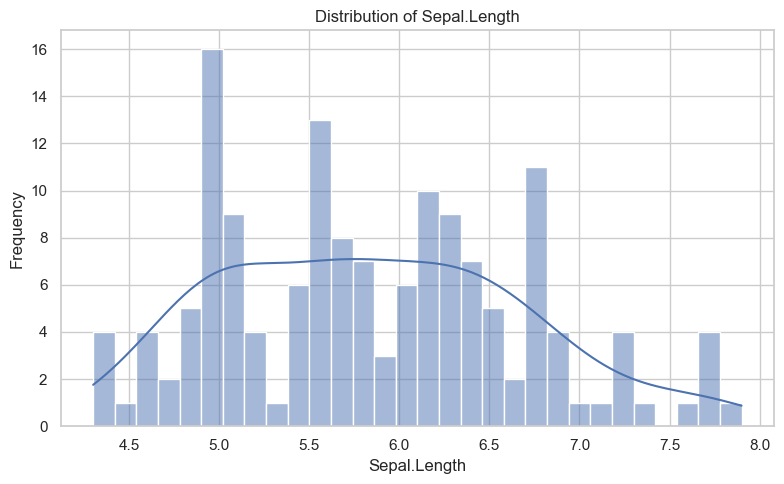

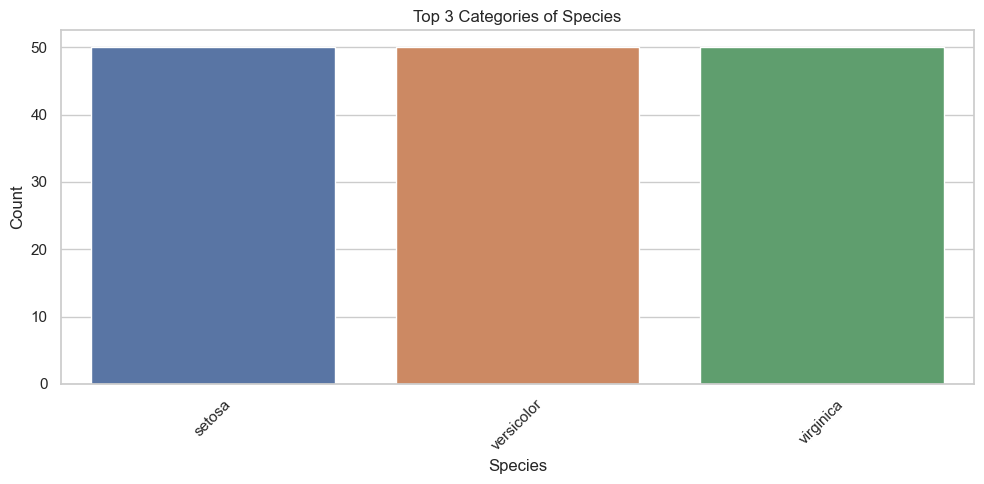

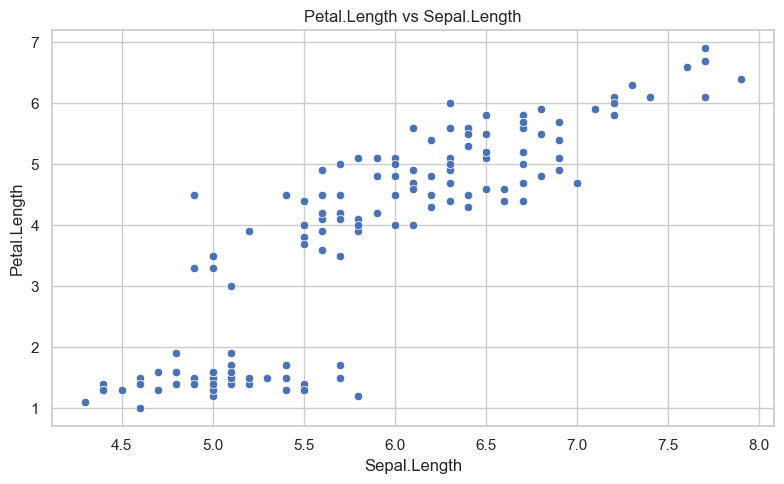

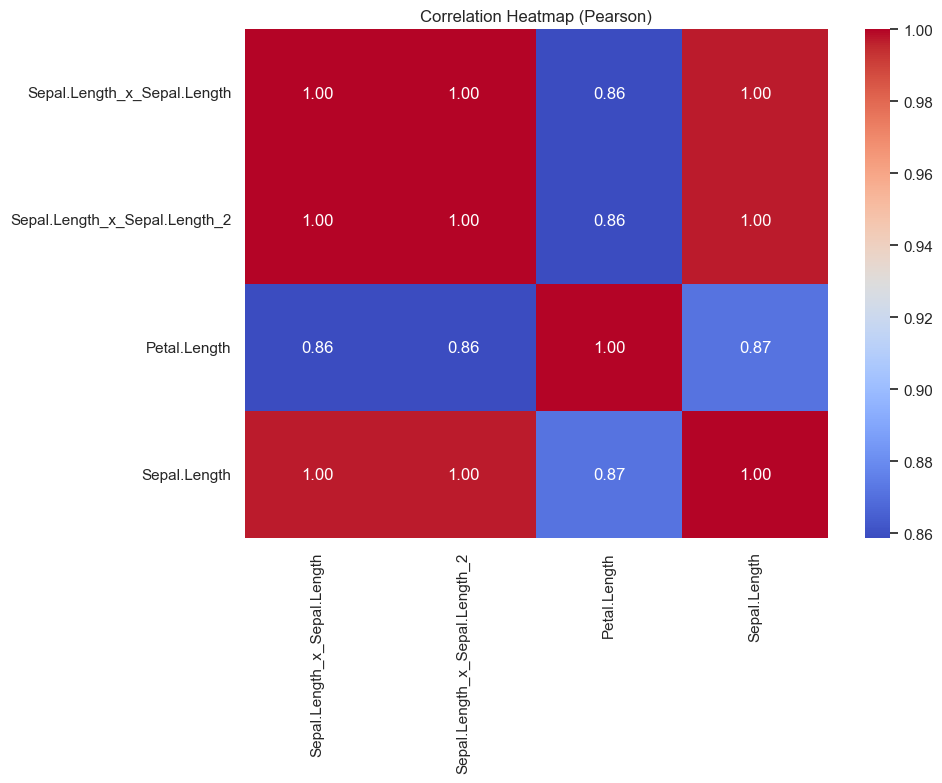

In [21]:
# Example test run
if __name__ == "__main__":
    DATA_FILE = "engineered_dataset.csv"
    LOG_FILE = "feature_log.csv"

    try:
        df = load_data(DATA_FILE)
        log_df = load_log_file(LOG_FILE)

        payload = build_eda_payload(df, log_df=log_df)

        print("=" * 70)
        print("Engineered Dataset BASIC INFO")
        print("=" * 70)
        print(payload["basic_info"])

        print("\n" + "=" * 70)
        print("DATASET SUMMARY")
        print("=" * 70)
        print(payload["dataset_summary"])

        print("\n" + "=" * 70)
        print("COLUMN GROUPS")
        print("=" * 70)
        print(payload["column_groups"])

        print("\n" + "=" * 70)
        print("FEATURE SUMMARY TABLE")
        print("=" * 70)
        print(payload["feature_summary_table"])

        print("\n" + "=" * 70)
        print("VALID PLOT OPTIONS")
        print("=" * 70)
        print(payload["valid_plot_options"])

        print("\n" + "=" * 70)
        print("DEFAULT COLUMN SUGGESTIONS")
        print("=" * 70)
        print(payload["default_column_suggestions"])

        defaults = payload["default_column_suggestions"]
        metadata = payload["feature_metadata"]

        if defaults["histogram"] is not None:
            plot_histogram(df, defaults["histogram"], show=True)

        if defaults["countplot"] is not None:
            plot_countplot(df, defaults["countplot"], show=True)

        if defaults["scatter_x"] is not None and defaults["scatter_y"] is not None:
            plot_scatter(df, defaults["scatter_x"], defaults["scatter_y"], show=True)

        if len(payload["valid_plot_options"]["correlation"]["allowed_columns"]) >= 2:
            plot_correlation_heatmap(df, show=True)

        if defaults["original_vs_transformed"] is not None:
            plot_original_vs_transformed(
                df,
                transformed_col=defaults["original_vs_transformed"],
                metadata=metadata,
                show=True
            )

    except Exception as e:
        print(f"Error: {e}")